# Convolutional Neural Network (CNN) Demo in PyTorch

In this notebook, we will build **Convolutional Neural Networks (CNNs)** for image classification using the **CIFAR-10** dataset.

Our goal is to understand:

- Why do fully connected neural networks struggle with images?
- How does a convolutional layer extract useful patterns from an image?
- What do **filters, feature maps, and pooling** actually mean?
- How does a CNN learn to classify images?

We will compare a CNN with a normal **Feed Forward Neural Network (FFNN)** on the same CIFAR-10 task in terms of:

- Classification accuracy
- Number of parameters
- Training/convergence behaviour

We will look into deeper CNNs and also introduce the concept of overfitting.

In [1]:
# Import all the necessary libraries
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"We are using device: {device}")

We are using device: cuda


## CIFAR-10 Dataset

CIFAR-10 is a dataset of small color images belonging to **10 different classes**.

The 10 classes are:

**airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck**

Each image has size:

$$
32 \times 32
$$

and contains **3 color channels (RGB)**.

Therefore, a single image is represented as:

$$
32 \times 32 \times 3
$$

Unlike MNIST, which contained grayscale handwritten digits, CIFAR-10 contains **color images of real-world objects**.

This makes the classification problem considerably more challenging and gives us a good setting for understanding why CNNs are useful.

## Loading the CIFAR-10 Dataset
We have pre-loaded the dataset into our environment. We are going to write a custom PyTorch `Dataset` class to read these files.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Create a local directory in the Colab runtime
!mkdir -p /content/cifar10

# Extract the archive directly from your Drive to the local runtime
!tar -xzvf "/content/drive/MyDrive/cifar-10-python (1).tar.gz" -C /content/cifar10

cifar-10-batches-py/
cifar-10-batches-py/data_batch_4
cifar-10-batches-py/readme.html
cifar-10-batches-py/test_batch
cifar-10-batches-py/data_batch_3
cifar-10-batches-py/batches.meta
cifar-10-batches-py/data_batch_2
cifar-10-batches-py/data_batch_5
cifar-10-batches-py/data_batch_1


In [7]:
data_dir = '/content/cifar10/cifar-10-batches-py'

class CustomCIFAR10(Dataset):
    def __init__(self, data_dir, train=True, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self.data = []
        self.targets = []

        # CIFAR-10 splits data into 5 training batches and 1 test batch
        if train:
            file_names = [f'data_batch_{i}' for i in range(1, 6)]
        else:
            file_names = ['test_batch']

        # Loop through the files and load the pickle data
        for file_name in file_names:
            file_path = os.path.join(self.data_dir, file_name)
            with open(file_path, 'rb') as f:
                # encoding='bytes' is required for Python 3 to read CIFAR-10 pickles
                entry = pickle.load(f, encoding='bytes')
                self.data.append(entry[b'data'])
                self.targets.extend(entry[b'labels'])

        # Combine all batches into one massive numpy array
        self.data = np.vstack(self.data)

        # CIFAR-10 stores images as a flat 1D array of 3072 pixels.
        # We need to reshape it to (Number of Images, Channels, Height, Width)
        # 3072 = 3 channels * 32 height * 32 width
        self.data = self.data.reshape(-1, 3, 32, 32)

        # For PyTorch transforms (like ToTensor), the image needs to be (Height, Width, Channels)
        # So we transpose the dimensions: 0 (batch) stays same, 2 (height) and 3 (width) move up, 1 (channels) moves to the end
        self.data = self.data.transpose((0, 2, 3, 1))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img, target = self.data[idx], self.targets[idx]

        # Apply any transformations (like converting to PyTorch Tensors)
        if self.transform is not None:
            img = self.transform(img)

        return img, target

In [8]:
# We need to convert our numpy arrays to PyTorch Tensors and scale pixels between 0 and 1
transform = transforms.Compose([
    transforms.ToTensor()
])

# Create our train and test datasets
train_dataset = CustomCIFAR10(data_dir=data_dir, train=True, transform=transform)
test_dataset = CustomCIFAR10(data_dir=data_dir, train=False, transform=transform)

# Create DataLoaders to pass data to our model in batches of 64 images at a time
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Number of training images: {len(train_dataset)}")
print(f"Number of testing images: {len(test_dataset)}")

Number of training images: 50000
Number of testing images: 10000


In [9]:
# --- Let's inspect our data dimensions! ---
print("=== Raw Dataset Shapes (Before Transformation) ===")
# CustomCIFAR10 stores the raw numpy array in the .data attribute
print(f"Train dataset raw shape: {train_dataset.data.shape} -> (Images, Height, Width, Channels)")
print(f"Test dataset raw shape:  {test_dataset.data.shape}\n")

print("=== Single Image Shape (After Transformation) ===")
# Let's grab the very first image and label from the training set
sample_image, sample_label = train_dataset[0]

# Notice how transforms.ToTensor() moved the Channels to the front!
# PyTorch always expects images in (Channels, Height, Width) format.
print(f"Transformed image shape: {sample_image.shape} -> (Channels, Height, Width)")
print(f"Image Data Type:         {sample_image.dtype}")
# transforms.ToTensor() also scales pixel values from [0, 255] down to [0.0, 1.0]
print(f"Pixel Value Range:       Min = {sample_image.min().item():.1f}, Max = {sample_image.max().item():.1f}\n")

print("=== DataLoader Batch Shape ===")
# Let's see what a single batch from our DataLoader looks like
dataiter = iter(train_loader)
batch_images, batch_labels = next(dataiter)

print(f"Batch images shape: {batch_images.shape} -> (Batch Size, Channels, Height, Width)")
print(f"Batch labels shape: {batch_labels.shape} -> 64 labels for our 64 images")

=== Raw Dataset Shapes (Before Transformation) ===
Train dataset raw shape: (50000, 32, 32, 3) -> (Images, Height, Width, Channels)
Test dataset raw shape:  (10000, 32, 32, 3)

=== Single Image Shape (After Transformation) ===
Transformed image shape: torch.Size([3, 32, 32]) -> (Channels, Height, Width)
Image Data Type:         torch.float32
Pixel Value Range:       Min = 0.0, Max = 1.0

=== DataLoader Batch Shape ===
Batch images shape: torch.Size([64, 3, 32, 32]) -> (Batch Size, Channels, Height, Width)
Batch labels shape: torch.Size([64]) -> 64 labels for our 64 images


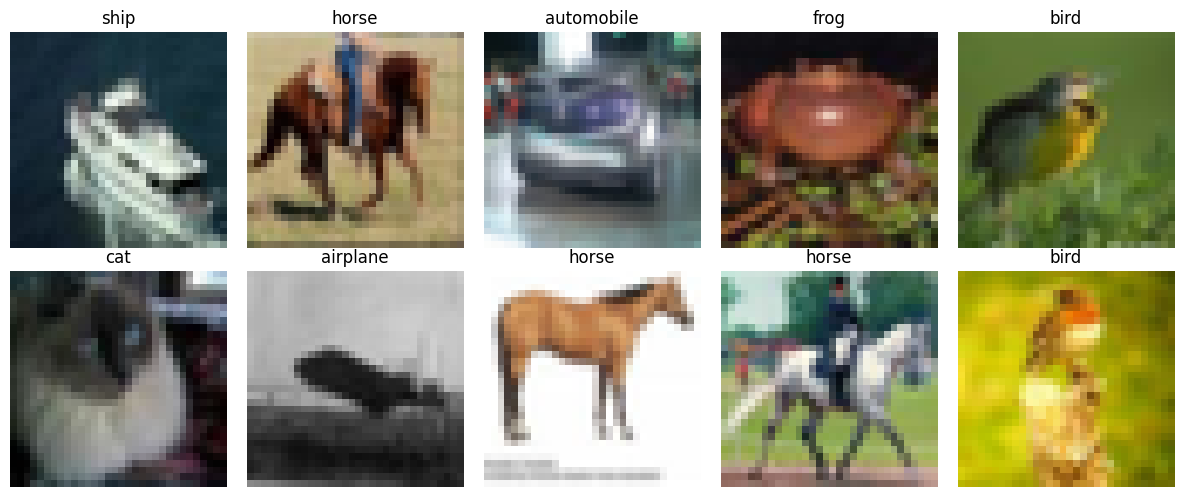

In [10]:
# Let's visualize what we just loaded!
# Load the label names from the batches.meta file
meta_file = os.path.join(data_dir, 'batches.meta')
with open(meta_file, 'rb') as f:
    meta_dict = pickle.load(f, encoding='bytes')
    # Decode bytes to strings for readability
    classes = [label.decode('utf-8') for label in meta_dict[b'label_names']]

# Get a single batch of images and labels from our DataLoader
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Plot the first 10 images in the batch
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for i in range(10):
    # PyTorch tensors are (Channels, Height, Width).
    # Matplotlib needs (Height, Width, Channels) to plot correctly, so we permute the dimensions.
    img = images[i].permute(1, 2, 0).numpy()

    axes[i].imshow(img)
    axes[i].set_title(classes[labels[i]])
    axes[i].axis('off')

plt.tight_layout()
plt.show()

##The Baseline: Feed Forward Neural Network (FNN)

Before we introduce CNNs, let's see how our model from the last class (the Feed Forward Network) handles CIFAR-10.

To use an FNN, we have to destroy the 2D shape of the image and "flatten" it.
A CIFAR-10 image is `32 (height) x 32 (width) x 3 (color channels)`.
When we flatten it, we get a single 1D array of `32 * 32 * 3 = 3072` numbers.

Let's build a simple FNN with two hidden layers. We will also write a quick helper function to count how many "learnable parameters" (weights and biases) our model has.

In [11]:
class FeedForwardNet(nn.Module):
    def __init__(self):
        super(FeedForwardNet, self).__init__()
        # Flatten layer to turn 3D image into 1D vector
        self.flatten = nn.Flatten()

        # 32*32*3 = 3072 input features
        self.fc1 = nn.Linear(3072, 512)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(512, 128)
        self.relu2 = nn.ReLU()

        # 10 output features for our 10 classes (dog, cat, car, etc.)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.fc3(x)
        return x

# Helper function to count parameters
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

fnn_model = FeedForwardNet().to(device)
print(f"FNN created! It has {count_parameters(fnn_model):,} learnable parameters.")

FNN created! It has 1,640,330 learnable parameters.


##The Upgrade: Convolutional Neural Network (CNN)

Look at how many parameters the FNN has! Over 1.6 million. That's a lot for a tiny 32x32 image.

Now, let's build our CNN. A CNN preserves the 2D structure of the image and uses two new types of layers:

1. **`nn.Conv2d` (Convolutional Layer):** Instead of connecting every pixel to a neuron, it slides a tiny window (e.g., 3x3 pixels) over the image. This window acts as a filter that learns to detect specific patterns like horizontal lines, colors, or circles.
2. **`nn.MaxPool2d` (Pooling Layer):** This layer shrinks the image. It looks at a 2x2 grid of pixels and just keeps the maximum value. This reduces our computational load and helps the network focus on the most prominent features.

At the very end of the CNN, after we have extracted all the good features, we flatten the output and use a standard Linear layer to make the final 10-class prediction.

In [12]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        # 1st Convolutional Block
        # Input: 3 channels (RGB). Output: 16 feature maps. Filter size: 3x3.
        # padding=1 keeps the image size the same (32x32) after convolution
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        # MaxPool shrinks image by half: 32x32 -> 16x16
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # 2nd Convolutional Block
        # Input: 16 channels. Output: 32 feature maps.
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        # MaxPool shrinks image by half again: 16x16 -> 8x8
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.flatten = nn.Flatten()

        # After two poolings, our 32x32 image is now 8x8.
        # We have 32 feature maps, so total flattened features = 32 * 8 * 8 = 2048
        self.fc1 = nn.Linear(32 * 8 * 8, 128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # Pass through block 1
        x = self.pool1(self.relu1(self.conv1(x)))
        # Pass through block 2
        x = self.pool2(self.relu2(self.conv2(x)))

        # Flatten and pass through linear layers
        x = self.flatten(x)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

cnn_model = SimpleCNN().to(device)
print(f"CNN created! It has {count_parameters(cnn_model):,} learnable parameters.")

CNN created! It has 268,650 learnable parameters.


## 4. The Training Loop

Notice that the CNN has **far fewer parameters** than the FNN!
* FNN: ~1.6 Million parameters
* CNN: ~260,000 parameters

Despite being smaller, the CNN should perform much better because its architecture is designed specifically for images.

We will use **CrossEntropyLoss** (standard for classification) and the **Adam optimizer** (adjusts the learning rate automatically for faster convergence).

In [13]:
def train_and_evaluate(model, train_loader, test_loader, epochs=10):
    # Loss and Optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Dictionaries to store accuracy and loss for plotting later
    # UPDATED: Added 'train_accuracy' to the history dictionary
    history = {'train_loss': [], 'train_accuracy': [], 'test_accuracy': []}

    for epoch in range(epochs):
        # --- TRAINING PHASE ---
        model.train() # Tell the model it is in training mode
        running_loss = 0.0

        # UPDATED: Variables to track training accuracy
        train_correct = 0
        train_total = 0

        for images, labels in train_loader:
            # Move data to GPU if available
            images, labels = images.to(device), labels.to(device)

            # 1. Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # UPDATED: Calculate training accuracy for this batch
            _, predicted = torch.max(outputs.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

            # 2. Backward pass (calculate gradients)
            optimizer.zero_grad() # Clear old gradients
            loss.backward()

            # 3. Optimize (update weights)
            optimizer.step()

            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        # UPDATED: Calculate final training accuracy for the epoch
        train_accuracy = 100 * train_correct / train_total

        history['train_loss'].append(avg_train_loss)
        history['train_accuracy'].append(train_accuracy)

        # --- EVALUATION PHASE ---
        model.eval() # Tell the model it is in testing mode
        test_correct = 0
        test_total = 0

        # torch.no_grad() saves memory and speeds up testing since we don't need gradients
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)

                # Get the index of the highest probability
                _, predicted = torch.max(outputs.data, 1)
                test_total += labels.size(0)
                test_correct += (predicted == labels).sum().item()

        test_accuracy = 100 * test_correct / test_total
        history['test_accuracy'].append(test_accuracy)

        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Train Acc: {train_accuracy:.2f}% | Test Acc: {test_accuracy:.2f}%")

    return history

In [14]:
# Train the Feed Forward Network
print("=== Training the FNN (Baseline) ===")
fnn_history = train_and_evaluate(fnn_model, train_loader, test_loader, epochs=10)

=== Training the FNN (Baseline) ===
Epoch [1/10] | Train Loss: 1.8702 | Train Acc: 31.94% | Test Acc: 38.87%
Epoch [2/10] | Train Loss: 1.6794 | Train Acc: 39.58% | Test Acc: 42.34%
Epoch [3/10] | Train Loss: 1.5863 | Train Acc: 43.25% | Test Acc: 41.37%
Epoch [4/10] | Train Loss: 1.5318 | Train Acc: 45.12% | Test Acc: 45.14%
Epoch [5/10] | Train Loss: 1.4871 | Train Acc: 46.78% | Test Acc: 47.79%
Epoch [6/10] | Train Loss: 1.4490 | Train Acc: 48.40% | Test Acc: 45.40%
Epoch [7/10] | Train Loss: 1.4293 | Train Acc: 48.97% | Test Acc: 48.17%
Epoch [8/10] | Train Loss: 1.4056 | Train Acc: 50.00% | Test Acc: 47.96%
Epoch [9/10] | Train Loss: 1.3843 | Train Acc: 50.50% | Test Acc: 48.84%
Epoch [10/10] | Train Loss: 1.3620 | Train Acc: 51.51% | Test Acc: 49.51%


In [15]:
# Train the Convolutional Neural Network
print("\n=== Training the CNN (The Upgrade) ===")
cnn_history = train_and_evaluate(cnn_model, train_loader, test_loader, epochs=10)


=== Training the CNN (The Upgrade) ===
Epoch [1/10] | Train Loss: 1.5940 | Train Acc: 42.59% | Test Acc: 53.26%
Epoch [2/10] | Train Loss: 1.2558 | Train Acc: 55.21% | Test Acc: 57.46%
Epoch [3/10] | Train Loss: 1.1034 | Train Acc: 61.12% | Test Acc: 61.92%
Epoch [4/10] | Train Loss: 0.9991 | Train Acc: 64.94% | Test Acc: 64.39%
Epoch [5/10] | Train Loss: 0.9312 | Train Acc: 67.39% | Test Acc: 65.40%
Epoch [6/10] | Train Loss: 0.8742 | Train Acc: 69.25% | Test Acc: 66.26%
Epoch [7/10] | Train Loss: 0.8217 | Train Acc: 71.34% | Test Acc: 68.06%
Epoch [8/10] | Train Loss: 0.7749 | Train Acc: 73.00% | Test Acc: 68.45%
Epoch [9/10] | Train Loss: 0.7327 | Train Acc: 74.30% | Test Acc: 69.10%
Epoch [10/10] | Train Loss: 0.6900 | Train Acc: 75.87% | Test Acc: 69.43%


##Comparison: FNN vs. CNN 🏆

Let's look at the data we just gathered.

| Metric | FNN (Feed Forward) | CNN (Convolutional) |
| :--- | :--- | :--- |
| **Parameters to Learn** | ~1.6 Million (Huge!) | ~260k (Lightweight!) |
| **Spatial Awareness?** | No (Flattened immediately) | Yes (Using 2D filters) |
| **Accuracy (approx)** | Plateaus around ~50% | Easily reaches ~65-70% |

Even though the CNN has about **6x fewer parameters**, it significantly outperforms the FNN. The FNN struggles to understand spatial structure of images. For instance, it fails to figure out what a dog looks like because the dog's pixels are scattered all over a 1D line. The CNN looks at the 2D image directly, finding edges, fur textures, and shapes.

Let's plot the training curves to visualize their learning journey!

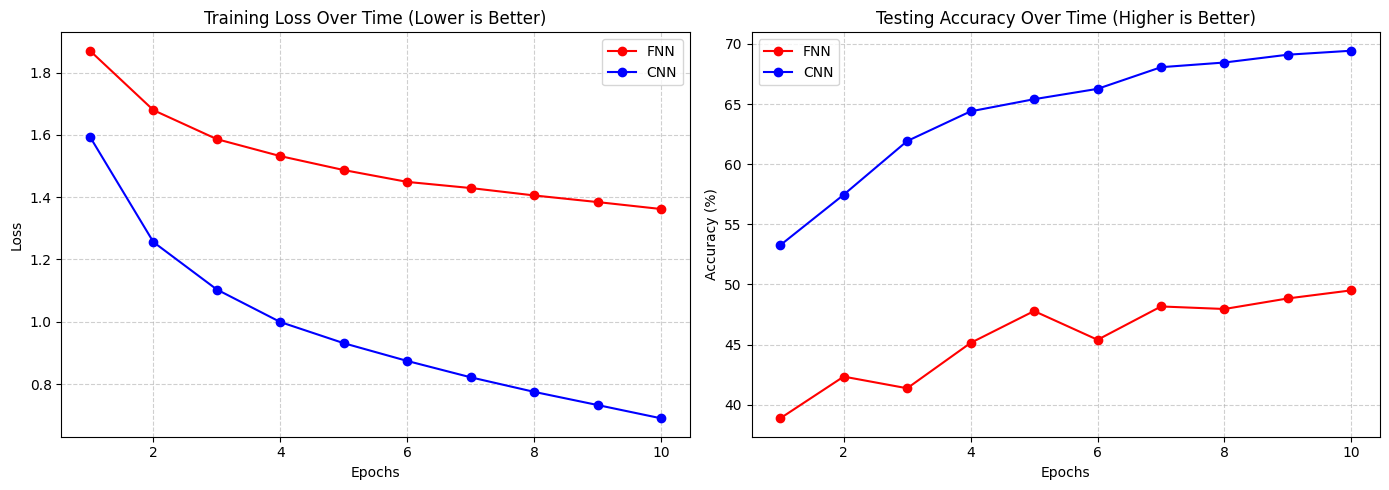

In [16]:
# Plotting the comparison
epochs_range = range(1, 11)

plt.figure(figsize=(14, 5))

# Plot 1: Training Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, fnn_history['train_loss'], label='FNN', color='red', marker='o')
plt.plot(epochs_range, cnn_history['train_loss'], label='CNN', color='blue', marker='o')
plt.title('Training Loss Over Time (Lower is Better)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Testing Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, fnn_history['test_accuracy'], label='FNN', color='red', marker='o')
plt.plot(epochs_range, cnn_history['test_accuracy'], label='CNN', color='blue', marker='o')
plt.title('Testing Accuracy Over Time (Higher is Better)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

##Visualizing Predictions

Accuracy metrics are great, but as deep learning practitioners, we always want to look at our data! Let's take a batch of images from our test set, pass them through our trained CNN, and see what it gets right (and what it gets wrong).

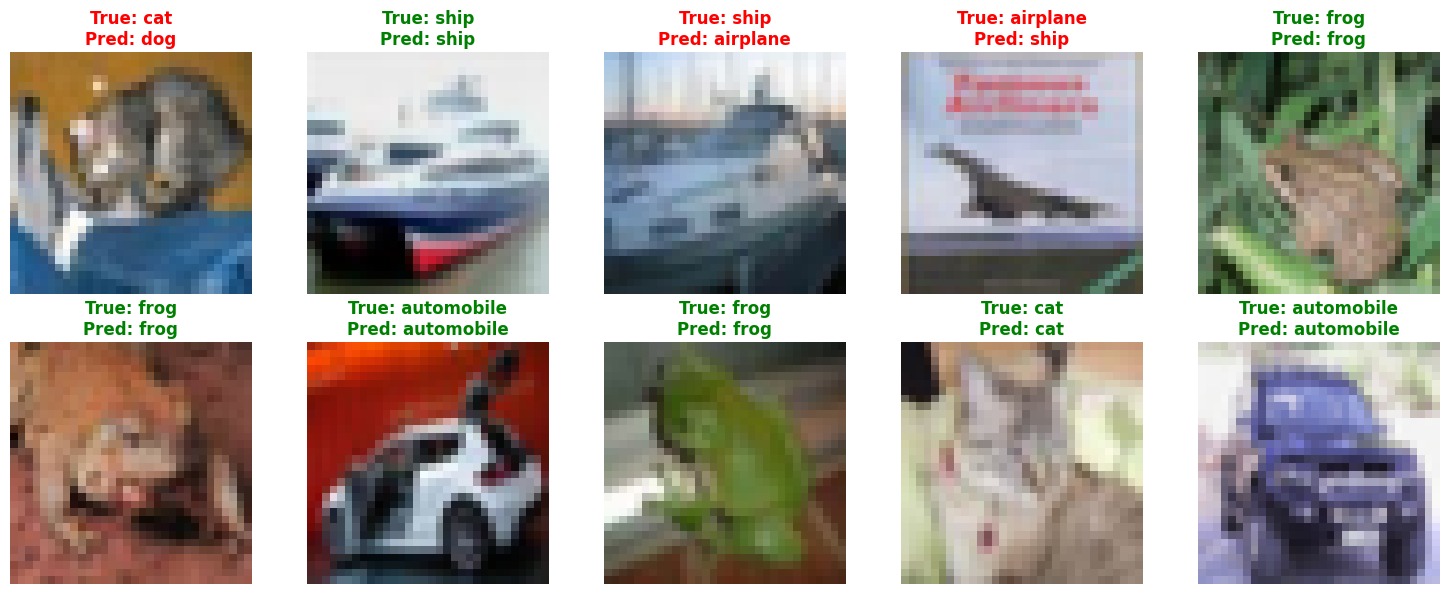

In [17]:
# Get a batch of test images
dataiter = iter(test_loader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

# Get predictions from our Simple CNN
cnn_model.eval()
with torch.no_grad():
    outputs = cnn_model(images)
    _, predicted = torch.max(outputs, 1)

# Move back to CPU for plotting
images = images.cpu()
labels = labels.cpu()
predicted = predicted.cpu()

# Plot 10 images with their predictions
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i in range(10):
    img = images[i].permute(1, 2, 0).numpy()
    true_label = classes[labels[i]]
    pred_label = classes[predicted[i]]

    axes[i].imshow(img)

    # Color code: Green if correct, Red if wrong
    color = 'green' if true_label == pred_label else 'red'
    axes[i].set_title(f"True: {true_label}\nPred: {pred_label}", color=color, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

##Scaling Up: Why Go Deeper?

Our Simple CNN did a good job, but in the real world, neural networks are much deeper. Why does adding more layers help?

**The Hierarchy of Features:**
Deep networks learn in a hierarchy.
* **Layer 1 (Shallow):** Learns very basic things—straight lines, edges, simple color gradients.
* **Layer 2 (Middle):** Combines those lines to find shapes—circles, corners, textures (like fur or metal).
* **Layer 3 (Deep):** Combines those shapes into recognizable parts—wheels, dog ears, airplane wings.

**The Golden Rule of CNN Architecture:**
As we add more layers, we use `MaxPool2d` to shrink the spatial dimensions (Height x Width) of the image. Because the image is getting smaller, we can afford to make it "thicker" by adding more filters (Channels).
* Notice how our channels will scale up: `32 -> 64 -> 128` as the image shrinks from `32x32 -> 16x16 -> 8x8 -> 4x4`.

Let's build a deeper CNN to see this scaling in action!

In [18]:
class DeeperCNN(nn.Module):
    def __init__(self):
        super(DeeperCNN, self).__init__()

        # Block 1: 3 channels in -> 32 channels out
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2) # Image size: 32 -> 16

        # Block 2: 32 channels in -> 64 channels out
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2) # Image size: 16 -> 8

        # Block 3: 64 channels in -> 128 channels out (New Layer!)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(2, 2) # Image size: 8 -> 4

        self.flatten = nn.Flatten()

        # Calculate final size: 128 channels * 4 height * 4 width = 2048 features
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.relu4 = nn.ReLU()
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.pool3(self.relu3(self.conv3(x))) # New deeper features!

        x = self.flatten(x)
        x = self.relu4(self.fc1(x))
        x = self.fc2(x)
        return x

deeper_cnn = DeeperCNN().to(device)
print(f"Deeper CNN created! It has {count_parameters(deeper_cnn):,} parameters.")
print(f"It has ~600k parameters. That's still ONE MILLION FEWER parameters than our Baseline FNN (1.6m)!")

Deeper CNN created! It has 620,362 parameters.
It has ~600k parameters. That's still ONE MILLION FEWER parameters than our Baseline FNN (1.6m)!


In [19]:
# Let's train the deeper model!
# (Note: In a real class, you might drop epochs to 5 to save time, but let's stick to 10 for the accuracy bump)

print("=== Training the Deeper CNN ===")
deeper_history = train_and_evaluate(deeper_cnn, train_loader, test_loader, epochs=10)

=== Training the Deeper CNN ===
Epoch [1/10] | Train Loss: 1.5260 | Train Acc: 44.23% | Test Acc: 54.12%
Epoch [2/10] | Train Loss: 1.0858 | Train Acc: 61.34% | Test Acc: 64.15%
Epoch [3/10] | Train Loss: 0.8950 | Train Acc: 68.59% | Test Acc: 68.26%
Epoch [4/10] | Train Loss: 0.7774 | Train Acc: 72.80% | Test Acc: 69.92%
Epoch [5/10] | Train Loss: 0.6870 | Train Acc: 76.06% | Test Acc: 72.10%
Epoch [6/10] | Train Loss: 0.6143 | Train Acc: 78.51% | Test Acc: 73.53%
Epoch [7/10] | Train Loss: 0.5431 | Train Acc: 81.07% | Test Acc: 74.14%
Epoch [8/10] | Train Loss: 0.4812 | Train Acc: 83.14% | Test Acc: 73.49%
Epoch [9/10] | Train Loss: 0.4223 | Train Acc: 85.29% | Test Acc: 73.92%
Epoch [10/10] | Train Loss: 0.3703 | Train Acc: 87.01% | Test Acc: 73.55%


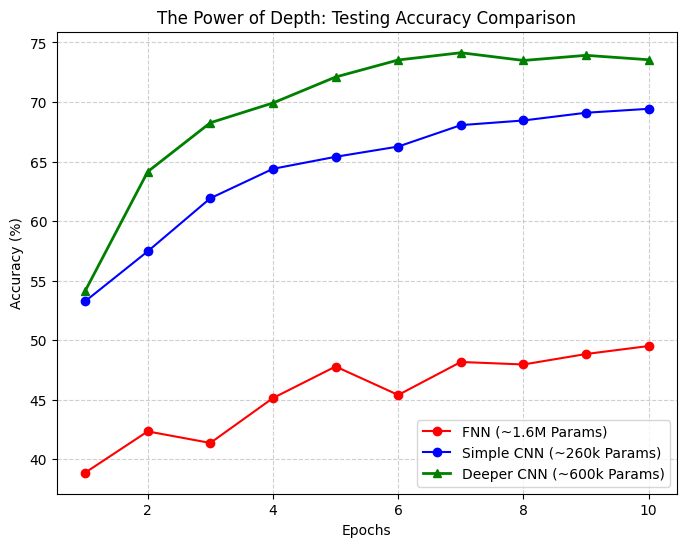

In [20]:
# Let's compare all three models together!
epochs_range = range(1, 11)

plt.figure(figsize=(8, 6))

# Plot Testing Accuracy for all 3
plt.plot(epochs_range, fnn_history['test_accuracy'], label='FNN (~1.6M Params)', color='red', marker='o')
plt.plot(epochs_range, cnn_history['test_accuracy'], label='Simple CNN (~260k Params)', color='blue', marker='o')
plt.plot(epochs_range, deeper_history['test_accuracy'], label='Deeper CNN (~600k Params)', color='green', marker='^', linewidth=2)

plt.title('The Power of Depth: Testing Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

##Changing the Filter Size

In our `SimpleCNN`, we used a `kernel_size=3` (a 3x3 pixel magnifying glass) and `padding=1` (adding a 1-pixel border of zeros to keep the image size the same).

**What if we use a bigger magnifying glass, like 5x5, and REMOVE the padding?**

If we don't pad the edges, the image shrinks every time we apply a convolution.
* A 32x32 image with a 5x5 filter shrinks to 28x28 (we lose 2 pixels on every edge).
* Then we Pool (halve it) to 14x14.
* Another 5x5 filter shrinks it to 10x10.
* Then we Pool (halve it) to 5x5.

Let's build it and see how the math changes the flattened dimension!

In [21]:
class LargeFilterCNN(nn.Module):
    def __init__(self):
        super(LargeFilterCNN, self).__init__()

        # Block 1: kernel_size=5, NO PADDING.
        # Image size: 32x32 -> 28x28
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=5, padding=0)
        self.relu1 = nn.ReLU()
        # MaxPool shrinks image by half: 28x28 -> 14x14
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Block 2: kernel_size=5, NO PADDING.
        # Image size: 14x14 -> 10x10
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, padding=0)
        self.relu2 = nn.ReLU()
        # MaxPool shrinks image by half: 10x10 -> 5x5
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.flatten = nn.Flatten()

        # NEW FLATTEN SIZE: We have 32 feature maps, and the image is now 5x5.
        # Total features = 32 * 5 * 5 = 800
        self.fc1 = nn.Linear(32 * 5 * 5, 128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))

        x = self.flatten(x)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

large_filter_model = LargeFilterCNN().to(device)
print(f"Large Filter CNN created! Parameters: {count_parameters(large_filter_model):,}")
print("Notice that because the image shrank faster, the final linear layer is much smaller (800 inputs instead of 2048)!")

Large Filter CNN created! Parameters: 117,866
Notice that because the image shrank faster, the final linear layer is much smaller (800 inputs instead of 2048)!


In [22]:
print("=== Training the Deeper CNN ===")
deeper_history = train_and_evaluate(deeper_cnn, train_loader, test_loader, epochs=20)

=== Training the Deeper CNN ===
Epoch [1/20] | Train Loss: 0.3214 | Train Acc: 88.62% | Test Acc: 74.29%
Epoch [2/20] | Train Loss: 0.2700 | Train Acc: 90.39% | Test Acc: 74.22%
Epoch [3/20] | Train Loss: 0.2282 | Train Acc: 91.90% | Test Acc: 73.15%
Epoch [4/20] | Train Loss: 0.1989 | Train Acc: 93.01% | Test Acc: 73.80%
Epoch [5/20] | Train Loss: 0.1724 | Train Acc: 93.89% | Test Acc: 72.96%
Epoch [6/20] | Train Loss: 0.1508 | Train Acc: 94.72% | Test Acc: 72.78%
Epoch [7/20] | Train Loss: 0.1348 | Train Acc: 95.24% | Test Acc: 72.89%
Epoch [8/20] | Train Loss: 0.1189 | Train Acc: 95.77% | Test Acc: 72.54%
Epoch [9/20] | Train Loss: 0.1109 | Train Acc: 96.03% | Test Acc: 72.72%
Epoch [10/20] | Train Loss: 0.1052 | Train Acc: 96.30% | Test Acc: 74.02%
Epoch [11/20] | Train Loss: 0.0920 | Train Acc: 96.78% | Test Acc: 73.45%
Epoch [12/20] | Train Loss: 0.0919 | Train Acc: 96.72% | Test Acc: 72.70%
Epoch [13/20] | Train Loss: 0.0919 | Train Acc: 96.73% | Test Acc: 72.54%
Epoch [14/20] |

##The Enemy of Deep Learning: Overfitting

If you looked closely at the training curves for our `DeeperCNN`, you might have noticed something worrying. By Epoch 10, our training accuracy was probably soaring past 90%, but our testing accuracy was stuck around 70-75%.

**This is called Overfitting.**
The model is getting *so* good at recognizing the specific dogs and cats in the training set that it starts memorizing them instead of learning general rules. It's like memorizing an exam's answer key instead of learning the math.

**How do we fix this? Enter: Dropout.**
Dropout is a regularization technique. During training, it randomly "turns off" (drops out) a percentage of the neurons in a layer.
* Why? It forces the network to not rely too heavily on any single feature (like a specific pixel or edge). The network has to learn redundant, robust features.

In [23]:
class DropoutCNN(nn.Module):
    def __init__(self):
        super(DropoutCNN, self).__init__()

        # Same exact Convolutional base as our DeeperCNN
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(2, 2)

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.relu4 = nn.ReLU()

        # --- NEW LAYER: DROPOUT ---
        # During training, randomly zero out 50% of the elements
        self.dropout = nn.Dropout(p=0.5)

        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.pool3(self.relu3(self.conv3(x)))

        x = self.flatten(x)
        x = self.relu4(self.fc1(x))

        # Apply dropout right before the final prediction
        x = self.dropout(x)
        x = self.fc2(x)
        return x

dropout_cnn = DropoutCNN().to(device)
print(f"Dropout CNN created! It has {count_parameters(dropout_cnn):,} parameters.")
print("Notice the parameter count is EXACTLY the same as DeeperCNN. Dropout doesn't add weights; it just randomly disables them!")

Dropout CNN created! It has 620,362 parameters.
Notice the parameter count is EXACTLY the same as DeeperCNN. Dropout doesn't add weights; it just randomly disables them!


In [24]:
# Let's train the Dropout model and see if it stops memorizing!
print("=== Training the Dropout CNN ===")
dropout_history = train_and_evaluate(dropout_cnn, train_loader, test_loader, epochs=30)

=== Training the Dropout CNN ===
Epoch [1/30] | Train Loss: 1.6471 | Train Acc: 39.23% | Test Acc: 52.06%
Epoch [2/30] | Train Loss: 1.2752 | Train Acc: 53.92% | Test Acc: 61.16%
Epoch [3/30] | Train Loss: 1.0894 | Train Acc: 61.54% | Test Acc: 65.70%
Epoch [4/30] | Train Loss: 0.9703 | Train Acc: 66.15% | Test Acc: 68.92%
Epoch [5/30] | Train Loss: 0.8851 | Train Acc: 69.10% | Test Acc: 70.43%
Epoch [6/30] | Train Loss: 0.8131 | Train Acc: 71.68% | Test Acc: 70.93%
Epoch [7/30] | Train Loss: 0.7580 | Train Acc: 73.63% | Test Acc: 73.70%
Epoch [8/30] | Train Loss: 0.7068 | Train Acc: 75.48% | Test Acc: 73.12%
Epoch [9/30] | Train Loss: 0.6618 | Train Acc: 76.86% | Test Acc: 72.68%
Epoch [10/30] | Train Loss: 0.6236 | Train Acc: 78.23% | Test Acc: 73.00%
Epoch [11/30] | Train Loss: 0.5879 | Train Acc: 79.32% | Test Acc: 74.26%
Epoch [12/30] | Train Loss: 0.5435 | Train Acc: 80.73% | Test Acc: 74.86%
Epoch [13/30] | Train Loss: 0.5288 | Train Acc: 81.14% | Test Acc: 75.56%
Epoch [14/30] 